# Car Detection in Snow – Main Notebook
**Course:** D7047E Advanced Deep Learning | LTU VT2026  
**Dataset:** [Nordic Vehicle Dataset (NVD)](https://nvd.ltu-ai.dev/)  
**Base model:** YOLOv9 via `ultralytics`

---

This is the single entry-point notebook for the project. It is organised into the following sections:

1. [Environment & Imports](#1-environment--imports)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
3. [Dataset Preparation](#3-dataset-preparation)
4. [Training](#4-training)
   - 4.1 Zero-shot baseline — YOLOv9 (COCO-pretrained, no fine-tuning)
   - 4.2 YOLOv9 fine-tuning
   - 4.3 COCO-format conversion for RT-DETR
   - 4.4 RT-DETR zero-shot baseline
   - 4.5 RT-DETR fine-tuning
   - 4.6 Faster R-CNN fine-tuning
   - 4.7 Faster R-CNN zero-shot baseline
   - 4.8 Results comparison table
5. [Phase 3 — Augmentation Ablation & Hyperparameter Sweep](#phase-3)
   - 4.9 Augmentation preview
   - 4.9A YOLOv9 snow augmentation training
   - 4.9B YOLOv9 full augmentation training
   - 4.10A RT-DETR snow augmentation training
   - 4.10B RT-DETR full augmentation training
   - 4.11A Faster R-CNN snow augmentation training
   - 4.11B Faster R-CNN full augmentation training
   - 4.12 Augmentation ablation results
   - 4.13 Hyperparameter sweep
   - 4.14 Final model training
6. [Evaluation](#5-evaluation)
7. [Error Analysis](#6-error-analysis)


## 1. Environment & Imports

In [1]:

import os
import random
from pathlib import Path
import shutil

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import yaml

# Reproducibility
random.seed(42)
np.random.seed(42)

# Paths
ROOT       = Path(".").resolve()  # project root
DATA_RAW   = ROOT / "data" / "raw"
DATA_PROC  = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
RESULTS    = ROOT / "results"
FIGURES    = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(ROOT)
print(MODELS_DIR)
print("Paths OK")

ModuleNotFoundError: No module named 'cv2'

## 2. Exploratory Data Analysis (EDA)

In [ ]:

# -- EDA - Step 1: Load annotations ------------------------------------------
# NVD uses a FLAT layout: all splits share the same images/ and labels/ dirs.
# Each split loads only the frames listed in its .txt file.

import sys
sys.path.insert(0, str(ROOT / "scripts"))

from data_utils import load_yolo_split_from_txt, compute_stats
from data_utils.reporting import print_stats

# Load split paths from the recording-level config (avoids temporal leakage)
EDA_YAML = ROOT / "configs" / "data_rec_sub.yaml"
with open(EDA_YAML) as f:
    _cfg = yaml.safe_load(f)
_ds_root = (EDA_YAML.parent / _cfg["path"]).resolve()

CLASS_NAMES = ["car"]

train_split = load_yolo_split_from_txt(_ds_root / _cfg["train"], root=_ds_root, split_name="train", class_names=CLASS_NAMES)
val_split   = load_yolo_split_from_txt(_ds_root / _cfg["val"],   root=_ds_root, split_name="val",   class_names=CLASS_NAMES)
test_split  = load_yolo_split_from_txt(_ds_root / _cfg["test"],  root=_ds_root, split_name="test",  class_names=CLASS_NAMES)

splits = [train_split, val_split, test_split]

for split in splits:
    stats = compute_stats(split)
    print_stats(stats)



  Split : train
  Images: 4355
  Boxes : 13969  (avg 3.2 per image)
  Images without annotations: 0

  Class counts:
    car                   13969

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 3234
    Images with missing dims: 0


  Split : val
  Images: 2904
  Boxes : 9175  (avg 3.2 per image)
  Images without annotations: 0

  Class counts:
    car                    9175

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 2098
    Images with missing dims: 0


  Split : test
  Images: 1191
  Boxes : 3169  (avg 2.7 per image)
  Images without annotations: 0

  Class counts:
    car                    3169

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 950
    Images with missing dims: 0



In [4]:

# -- EDA - Annotation quality check ---
# Surfaces potential issues to document in the Methodology section:
#   - Images with no annotations (empty frames)
#   - Crowd boxes (iscrowd=1): groups annotated as one box, not per-instance
#   - Tiny boxes (<32x32 px): often truncated objects at frame edges or label noise
#   - Images where width/height was missing in the annotation file

for split in splits:
    stats = compute_stats(split)
    print(f"[{split.name}]  crowd={stats['crowd_boxes']}  "
          f"tiny={stats['tiny_boxes']}  "
          f"empty_images={stats['images_without_boxes']}  "
          f"missing_dims={stats['missing_dims']}")


[train]  crowd=0  tiny=3234  empty_images=0  missing_dims=0
[val]  crowd=0  tiny=2098  empty_images=0  missing_dims=0
[test]  crowd=0  tiny=950  empty_images=0  missing_dims=0


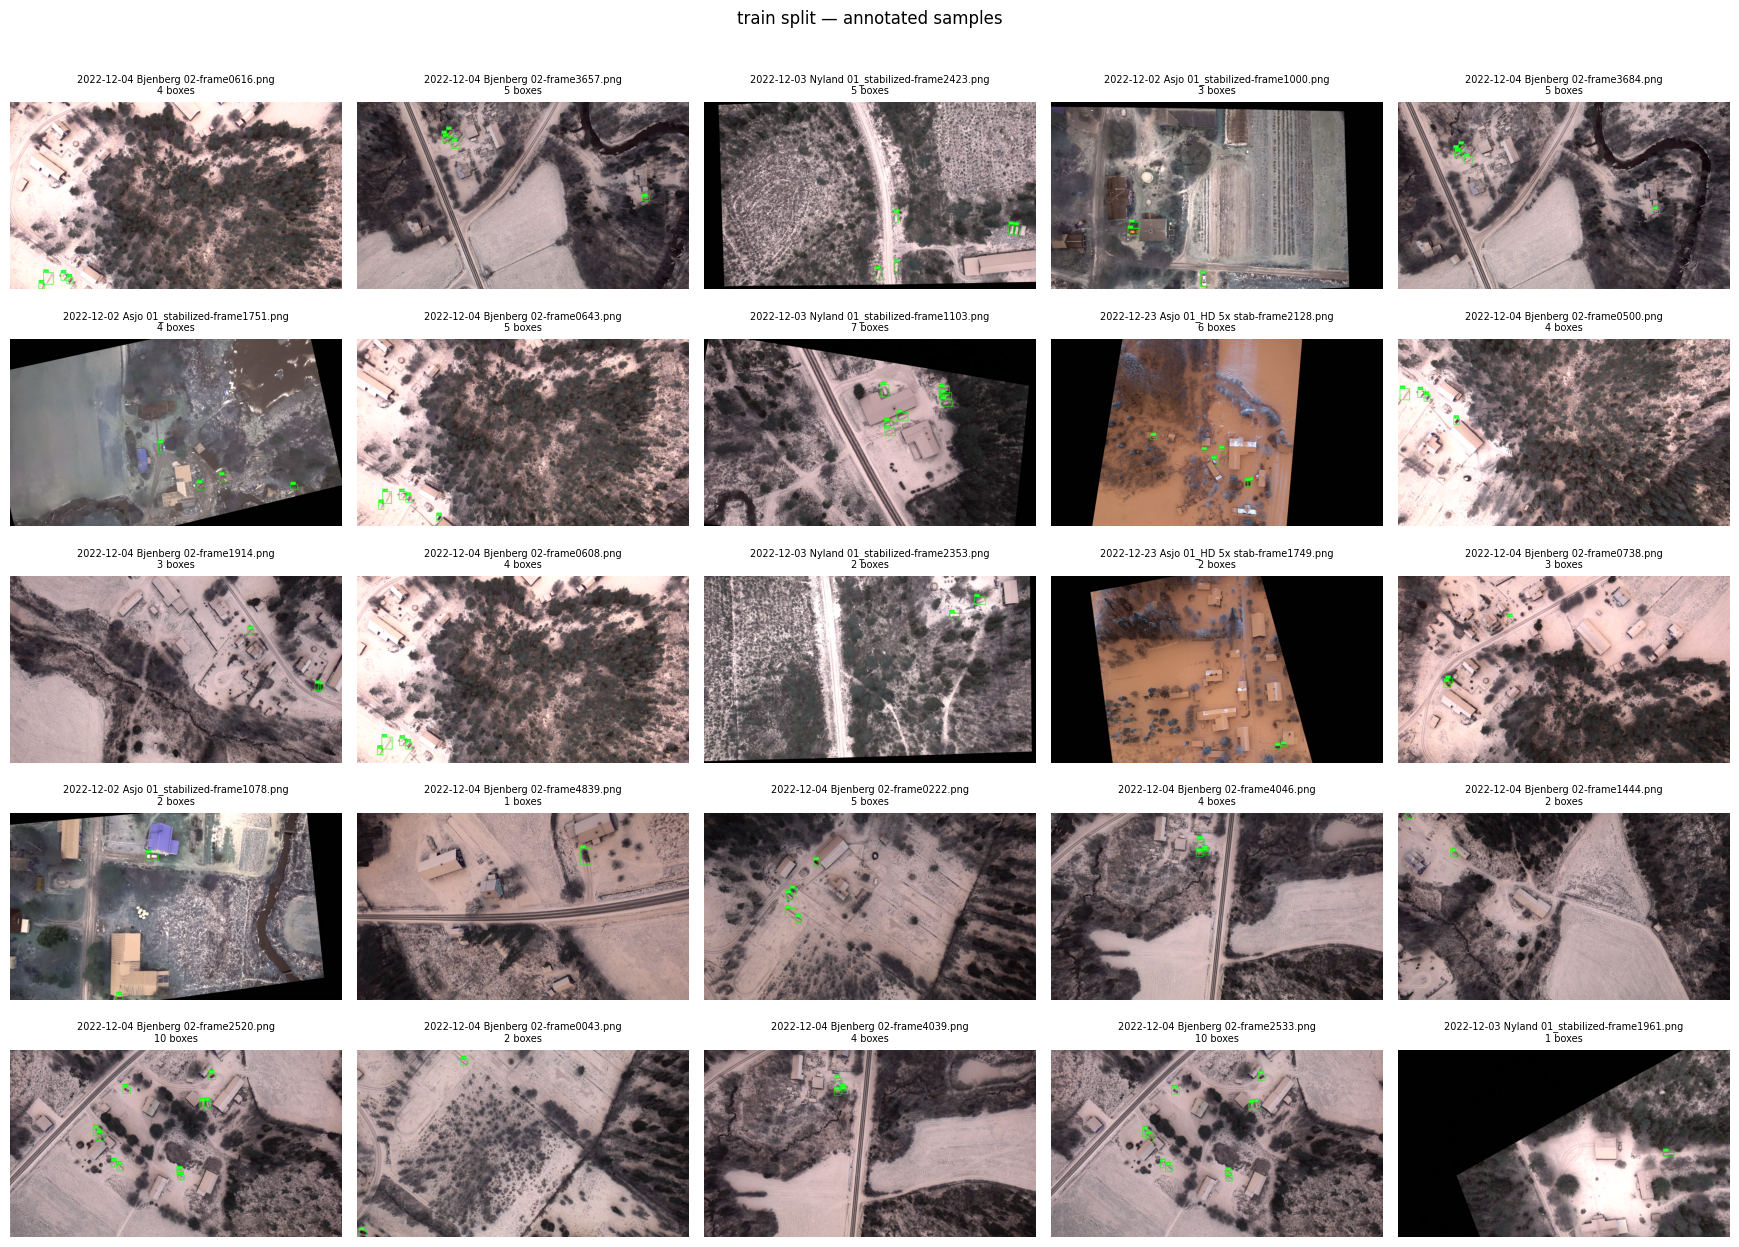

In [5]:

# -- EDA - Step 2: Visualise annotated samples --------------------------------
from eda.visualizer import plot_annotated_samples

fig = plot_annotated_samples(train_split, n=25, cols=5, seed=42)
fig.savefig(FIGURES / "eda_annotated_samples.png", bbox_inches="tight", dpi=120)
plt.show()


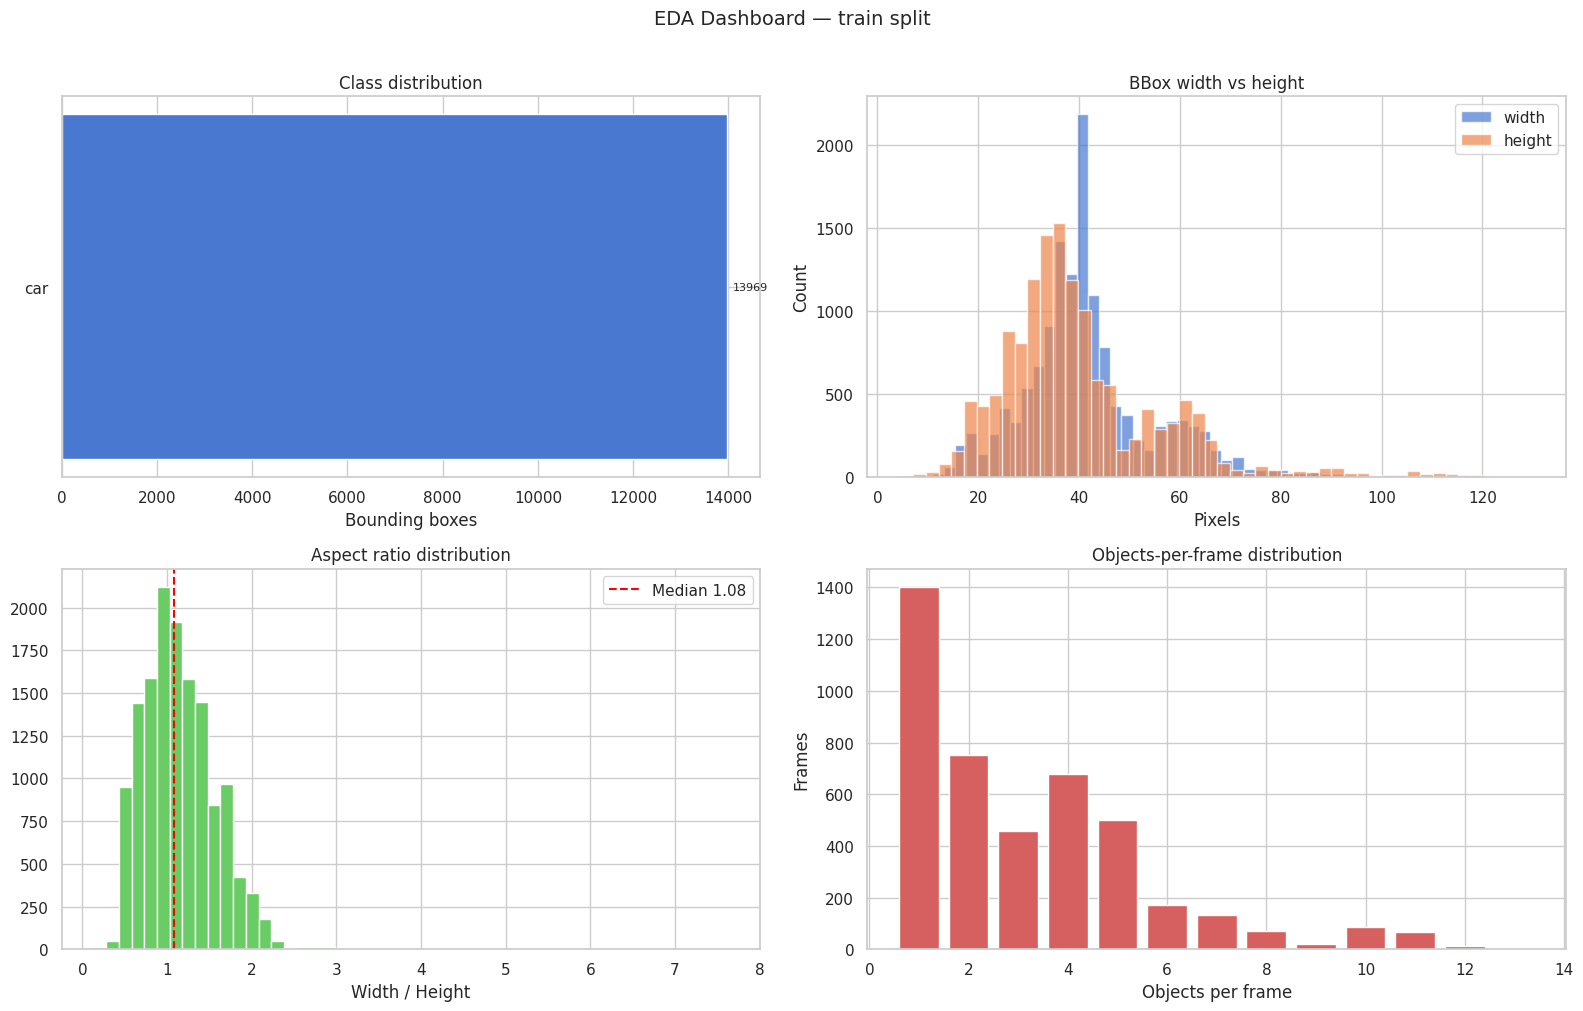

In [6]:

# -- EDA - Step 3: Distribution plots (all four in one dashboard) -------------
from eda.plots import plot_eda_dashboard

train_stats = compute_stats(train_split)

fig = plot_eda_dashboard(train_stats)
fig.savefig(FIGURES / "eda_dashboard_train.png", bbox_inches="tight", dpi=120)
plt.show()


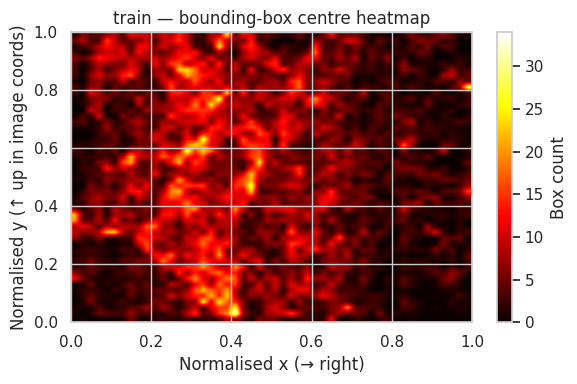

In [7]:

# -- EDA - Step 4: Bounding-box centre heatmap --------------------------------
from eda.visualizer import plot_bbox_heatmap

fig = plot_bbox_heatmap(train_stats)
fig.savefig(FIGURES / "eda_bbox_heatmap_train.png", bbox_inches="tight", dpi=120)
plt.show()


## 3. Dataset Preparation

No conversion needed – the NVD dataset is already in YOLO format.
`configs/data.yaml` points directly to the raw data and can be passed straight to ultralytics.

Run the cells below once to verify the dataset is correctly set up before training.

In [ ]:

# -- Dataset Preparation - Step 1: Inspect dataset stats ----------------------
# Run this cell to confirm all three splits load correctly from the config.
# Equivalent terminal command:
#   python scripts/inspect_dataset.py --data-yaml configs/data_rec_sub.yaml

import subprocess
import sys

result = subprocess.run(
    [sys.executable, "scripts/inspect_dataset.py",
     "--data-yaml", "configs/data_rec_sub.yaml"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)



  Split : train
  Images: 4355
  Boxes : 13969  (avg 3.2 per image)
  Images without annotations: 0

  Class counts:
    car                   13969

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 3234
    Images with missing dims: 0


  Split : val
  Images: 2904
  Boxes : 9175  (avg 3.2 per image)
  Images without annotations: 0

  Class counts:
    car                    9175

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 2098
    Images with missing dims: 0


  Split : test
  Images: 1191
  Boxes : 3169  (avg 2.7 per image)
  Images without annotations: 0

  Class counts:
    car                    3169

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 950
    Images with missing dims: 0




In [ ]:

# -- Dataset Preparation - Step 2: Verify annotations visually ----------------
# Draws bounding boxes on a sample of images and saves them to results/figures/.
# Equivalent terminal command:
#   python scripts/verify_annotations.py --data-yaml configs/data_rec_sub.yaml --split train --n 10 --output results/figures/verify_train/

import subprocess
import sys

result = subprocess.run(
    [sys.executable, "scripts/verify_annotations.py",
     "--data-yaml", "configs/data_rec_sub.yaml",
     "--split", "train",
     "--n", "10",
     "--output", "results/figures/verify_train/"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Saved 10 verified images to: results/figures/verify_train



## 4. Training

All training runs use the `scripts/training/` package (SRP/SoC design):  
- `training.models` — `TrainingConfig`, `EvalMetrics` dataclasses  
- `training.yolo_trainer` — YOLOv9 zero-shot eval + fine-tuning  
- `training.detr_trainer` — RT-DETR fine-tuning + eval  
- `training.frcnn_trainer` — Faster R-CNN fine-tuning + eval  
- `training.evaluator` — vendor result → `EvalMetrics` conversion  
- `training.results_writer` — CSV persistence  

Results accumulate in `results/model_comparison.csv`.

In [ ]:

# --- Phase 2 imports & shared config ----------------------------------------
import sys
from pathlib import Path

sys.path.insert(0, str(ROOT / "scripts"))

from training import (
    TrainingConfig,
    EvalMetrics,
    run_yolo_zero_shot_eval,
    run_yolo_fine_tuning,
    eval_yolo_checkpoint,
    run_detr_zero_shot_eval,
    run_detr_fine_tuning,
    eval_detr_checkpoint,
    run_frcnn_zero_shot_eval,
    run_frcnn_fine_tuning,
    eval_frcnn_checkpoint,
    save_zero_shot_result,
    append_comparison_row,
)

# ─── DATA SPLIT SELECTION ─────────────────────────────────────────────────────
# IMPORTANT: Use the recording-level split to avoid temporal leakage.
# The frame-level split (data.yaml) gives inflated val mAP (~0.99) because
# train and val share frames from the same video recordings.
#
# Options:
#   data_rec.yaml     — recording-level split (honest val, all train frames)
#   data_rec_sub.yaml — recording-level + subsampled (every 5th frame, less redundancy)

# Recording-level split with subsampled training frames (recommended)
DATA_YAML     = str(ROOT / "configs" / "data_rec_sub.yaml")

# Full recording-level split (alternative — more data but higher redundancy)
# DATA_YAML   = str(ROOT / "configs" / "data_rec.yaml")

COMPARISON_CSV   = str(RESULTS / "model_comparison.csv")
TRAIN_COCO_JSON  = str(DATA_PROC / "annotations" / "instances_train.json")
VAL_COCO_JSON    = str(DATA_PROC / "annotations" / "instances_val.json")
IMAGES_DIR       = str(DATA_RAW / "images")

# Change to "cpu" if no GPU is available
DEVICE = "0"

print("Phase 2 imports OK")
print(f"Data config: {DATA_YAML}")


Phase 2 imports OK


### 4.1 Zero-shot baseline

Run COCO-pretrained YOLOv9 on the NVD val set **without any fine-tuning**.  
This is the "before" anchor that makes fine-tuning gains meaningful.  
Result saved to `results/baseline_zero_shot.csv`.


In [12]:

# Run once before training anything — sets the "before fine-tuning" anchor.
baseline_metrics = run_yolo_zero_shot_eval(
    model_name="yolov9c.pt",
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
)


append_comparison_row(baseline_metrics, COMPARISON_CSV)

print(f"mAP@0.5     : {baseline_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {baseline_metrics.map50_95:.4f}")
print(f"Precision   : {baseline_metrics.precision:.4f}")
print(f"Recall      : {baseline_metrics.recall:.4f}")
print(f"FPS         : {baseline_metrics.fps:.1f}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: deeplab15group (deeplab15group-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
YOLOv9c summary (fused): 156 layers, 25,380,928 parameters, 0 gradients, 102.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1549.8±1645.4 MB/s, size: 3144.2 KB)
val: Scanning /Advance_deep_learning_labs/Project/data/raw/labels.cache... 2904 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2904/2904 193.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 182/182 4.2it/s 43.0s0.2ss
                   all       2904       9175     0.0216     0.0703    0.00163   0.000379
                person       2904       9175     0.0216     0.0703    0.00163   0.000379
Speed: 0.5ms preprocess, 6.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /runs/detect/val-2


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,151
eval/map50,0.00163
eval/map50_95,0.00038
eval/precision,0.02159
eval/recall,0.0703


[results_writer] Initialised comparison CSV → /Advance_deep_learning_labs/Project/results/model_comparison.csv
[results_writer] Appended row for 'yolov9c' → /Advance_deep_learning_labs/Project/results/model_comparison.csv
mAP@0.5     : 0.0016
mAP@0.5:0.95: 0.0004
Precision   : 0.0216
Recall      : 0.0703
FPS         : 151.0


### 4.2 YOLOv9 fine-tuning

Fine-tune `yolov9c` on the NVD training split.  
- Backbone frozen for the first run (`freeze=10`) — only the detection head adapts.  
- Best checkpoint copied to `models/yolov9_nvd_best.pt`.


In [ ]:

# ── 4.2 YOLOv9 fine-tuning (no custom augmentation — ablation baseline) ──────
# Uses recording-level subsampled split + YOLO native augmentation only.
# Generalization knobs (mixup, copy_paste, scale, hsv_v) are applied to ALL
# training runs so augmentation pipeline is the ONLY variable in the ablation.

yolo_config = TrainingConfig(
    model_name="yolov9c",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=0.001,
    freeze=None,
    device=DEVICE,
    output_dir=str(MODELS_DIR / "yolov9c"),
    run_name="yolov9_nvd",
    mosaic=1.0,
    close_mosaic=10,
    patience=25,
    # -- Generalization knobs (same for ALL 9 runs) --
    mixup=0.15,
    copy_paste=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.6,
)

yolo_best_pt = run_yolo_fine_tuning(yolo_config, aug_variant="none")

# Copy to canonical model path
yolo_dest = MODELS_DIR / "yolov9_nvd_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(yolo_best_pt, yolo_dest)
print(f"Best checkpoint → {yolo_dest}")

# Evaluate on val set
yolo_metrics = eval_yolo_checkpoint(
    weights=yolo_dest,
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
    model_label="YOLOv9c (fine-tuned)",
)
append_comparison_row(yolo_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {yolo_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {yolo_metrics.map50_95:.4f}")
print(f"Precision   : {yolo_metrics.precision:.4f}")
print(f"Recall      : {yolo_metrics.recall:.4f}")
print(f"FPS         : {yolo_metrics.fps:.1f}")


Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Advance_deep_learning_labs/Project/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1, multi_scale=0.0, name=yolov9_nvd, nbs=64, nms=False, opset=None, optimize=False, optim

wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


lr/pg0,▆███▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
lr/pg1,████▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁
lr/pg2,████▇▇▆▆▆▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▁▁
metrics/mAP50(B),▁▁▆▇████████████████████████████████████
metrics/mAP50-95(B),▂▁▃▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████████████
metrics/precision(B),▃▁▄▇▇▇██████████████████████████████████
metrics/recall(B),▁▁▆▆▇▇▇▇▇▇██▇▇██████████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


[INFO] Best checkpoint: /Advance_deep_learning_labs/Project/models/yolov9c/yolov9_nvd/weights/best.pt
Best checkpoint → /Advance_deep_learning_labs/Project/models/yolov9_nvd_best.pt


Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3064.8±344.9 MB/s, size: 3383.4 KB)
val: Scanning /Advance_deep_learning_labs/Project/data/raw/labels.cache... 2904 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2904/2904 329.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 182/182 2.9it/s 1:040.3sss
                   all       2904       9175      0.988      0.992      0.994      0.884
Speed: 1.1ms preprocess, 16.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /runs/detect/val-3


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,61.1
eval/map50,0.99439
eval/map50_95,0.88385
eval/precision,0.98832
eval/recall,0.99161


[results_writer] Appended row for 'YOLOv9c (fine-tuned)' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9944
mAP@0.5:0.95: 0.8839
Precision   : 0.9883
Recall      : 0.9916
FPS         : 61.1


### 4.3 COCO-format conversion for RT DETR

Before running DETR training, generate COCO JSON annotations from the YOLO split files.
This step creates `data/processed/annotations/instances_train.json` and `instances_val.json`.
</VSCode.Cell>
<VSCode.Cell language="python">

In [11]:

import subprocess
import sys

result = subprocess.run(
    [sys.executable, "scripts/prepare_coco_format.py",
     "--data-yaml", DATA_YAML,
     "--output", str(DATA_PROC)],
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
else:
    print("COCO format annotations generated successfully.")

[prepare_coco] Processing split 'train': 4355 images, 13969 boxes
[prepare_coco] Wrote /Advance_deep_learning_labs/Project/data/processed/annotations/instances_train.json
[prepare_coco] Processing split 'val': 2904 images, 9175 boxes
[prepare_coco] Wrote /Advance_deep_learning_labs/Project/data/processed/annotations/instances_val.json
[prepare_coco] Processing split 'test': 1191 images, 3169 boxes
[prepare_coco] Wrote /Advance_deep_learning_labs/Project/data/processed/annotations/instances_test.json

COCO format annotations generated successfully.


### 4.4 RT DETR Zero-shot baseline

In [15]:

# Zero-shot RT-DETR — COCO-pretrained, no fine-tuning
# Prerequisite: COCO JSON annotations must exist (run the prepare_coco_format cell first)
rtdetr_zs_metrics = run_detr_zero_shot_eval(
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    model_name="PekingU/rtdetr_r50vd",
    split="val",
    device_str=DEVICE,
)


append_comparison_row(rtdetr_zs_metrics, COMPARISON_CSV)

print(f"mAP@0.5     : {rtdetr_zs_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_zs_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_zs_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_zs_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_zs_metrics.fps:.1f}")


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,8.1
eval/map50,0.00618
eval/map50_95,0.00202
eval/precision,0.0325
eval/recall,0.0692


[results_writer] Appended row for 'rtdetr-r50vd' → /Advance_deep_learning_labs/Project/results/model_comparison.csv
mAP@0.5     : 0.0062
mAP@0.5:0.95: 0.0020
Precision   : 0.0325
Recall      : 0.0692
FPS         : 8.1


### 4.5 RT-DETR fine-tuning

In [ ]:

# ── 4.5 RT-DETR fine-tuning (no custom augmentation — ablation baseline) ─────
rtdetr_config = TrainingConfig(
    model_name="PekingU/rtdetr_r50vd",
    data_yaml="",              # RT-DETR uses COCO JSON, not data.yaml
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=1e-5,
    freeze=None,
    device=DEVICE,
    patience=25,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_nvd",
)

rtdetr_best_dir = run_detr_fine_tuning(
    rtdetr_config,
    train_json=TRAIN_COCO_JSON,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    aug_variant="none",
)
print(f"Best checkpoint → {rtdetr_best_dir}")

rtdetr_metrics = eval_detr_checkpoint(
    checkpoint_dir=rtdetr_best_dir,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    split="val",
    device_str=DEVICE,
    imgsz=1024,
)
append_comparison_row(rtdetr_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {rtdetr_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_metrics.fps:.1f}")


loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([1])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([1, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([1, 256])
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([2, 256])
mod

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


...

Best checkpoint → /Advance_deep_learning_labs/Project/models/rtdetr/rtdetr_nvd/best_checkpoint


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,7.4
eval/map50,0.98466
eval/map50_95,0.83751
eval/precision,0.9762
eval/recall,0.9696


[results_writer] Appended row for 'rtdetr-r50vd' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9847
mAP@0.5:0.95: 0.8375
Precision   : 0.9762
Recall      : 0.9696
FPS         : 7.4


### 4.6 Faster R-CNN 

Fine-tune `fasterrcnn_resnet50_fpn` (torchvision) on NVD.  
Reads YOLO-format labels directly — no COCO JSON required.  
Gives a classic two-stage detector baseline to compare against.


### Faster R-CNN Zero-shot Baseline


In [17]:

# Zero-shot Faster R-CNN — COCO-pretrained, no fine-tuning
frcnn_zs_metrics = run_frcnn_zero_shot_eval(
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
)

append_comparison_row(frcnn_zs_metrics, COMPARISON_CSV)

print(f"mAP@0.5     : {frcnn_zs_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_zs_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_zs_metrics.precision:.4f}")
print(f"Recall      : {frcnn_zs_metrics.recall:.4f}")
print(f"FPS         : {frcnn_zs_metrics.fps:.1f}")


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,11.3
eval/map50,0.0027
eval/map50_95,0.00181
eval/precision,0.0202
eval/recall,0.001


[results_writer] Appended row for 'fasterrcnn-resnet50-fpn' → /Advance_deep_learning_labs/Project/results/model_comparison.csv
mAP@0.5     : 0.0027
mAP@0.5:0.95: 0.0018
Precision   : 0.0202
Recall      : 0.0010
FPS         : 11.3


### 4.7 Faster R-CNN Fine-tuning


In [ ]:

# ── 4.7 Faster R-CNN fine-tuning (no custom augmentation — ablation baseline) ─
frcnn_config = TrainingConfig(
    model_name="fasterrcnn_resnet50_fpn",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=0.005,
    freeze=None,
    device=DEVICE,
    patience=25,
    output_dir=str(MODELS_DIR / "frcnn"),
    run_name="frcnn_nvd",
)

frcnn_best_pt = run_frcnn_fine_tuning(frcnn_config, data_yaml=DATA_YAML, aug_variant="none")

frcnn_dest = MODELS_DIR / "frcnn_nvd_best.pt"
shutil.copy2(frcnn_best_pt, frcnn_dest)
print(f"Best checkpoint → {frcnn_dest}")

frcnn_metrics = eval_frcnn_checkpoint(
    weights=frcnn_dest,
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
)
append_comparison_row(frcnn_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {frcnn_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_metrics.precision:.4f}")
print(f"Recall      : {frcnn_metrics.recall:.4f}")
print(f"FPS         : {frcnn_metrics.fps:.1f}")


[FRCNN]   1/100  loss=0.2674  val_mAP@0.5=0.8388  val_mAP@0.5:0.95=0.5102
[FRCNN] ✓ best=0.8388 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_nvd/best.pt
[FRCNN]   2/100  loss=0.1661  val_mAP@0.5=0.9263  val_mAP@0.5:0.95=0.6237
[FRCNN] ✓ best=0.9263 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_nvd/best.pt
[FRCNN]   3/100  loss=0.1362  val_mAP@0.5=0.9516  val_mAP@0.5:0.95=0.6610
[FRCNN] ✓ best=0.9516 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_nvd/best.pt
[FRCNN]   4/100  loss=0.1190  val_mAP@0.5=0.9630  val_mAP@0.5:0.95=0.6998
[FRCNN] ✓ best=0.9630 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_nvd/best.pt
[FRCNN]   5/100  loss=0.1064  val_mAP@0.5=0.9674  val_mAP@0.5:0.95=0.7198
[FRCNN] ✓ best=0.9674 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_nvd/best.pt
[FRCNN]   6/100  loss=0.0967  val_mAP@0.5=0.9706  val_mAP@0.5:0.95=0.7409
[FRCNN] ✓ best=0.9706 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_nvd/best.pt
[FRCNN]   

train/batch_loss,█▆▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▂▂▁▂▁▁▁▁▂▁▂▁▂▁▁▂▁▁▁▂▁▁▁
train/loss,█▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/map50,▁▇▇▇▇███████████████████████████████████
val/map50_95,▁▃▄▅▅▆▆▇▇▇▇▇████████████████████████████
train/batch_loss,0.01237
train/loss,0.02305
val/map50,0.97856
val/map50_95,0.81505


Best checkpoint → /Advance_deep_learning_labs/Project/models/frcnn_nvd_best.pt


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,9.9
eval/map50,0.97858
eval/map50_95,0.81501
eval/precision,0.983
eval/recall,0.9692


[results_writer] Appended row for 'fasterrcnn-resnet50-fpn' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9786
mAP@0.5:0.95: 0.8150
Precision   : 0.9830
Recall      : 0.9692
FPS         : 9.9


### 4.8 Results comparison table

Load `results/model_comparison.csv` and display all models side by side.


In [12]:

import pandas as pd

comparison_path = Path(COMPARISON_CSV)
if comparison_path.exists():
    df = pd.read_csv(comparison_path)
    # Highlight best value per numeric column
    numeric_cols = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "FPS"]
    display(
        df.style
          .highlight_max(subset=numeric_cols, color="lightgreen")
          .format({c: "{:.4f}" for c in numeric_cols if c != "FPS"})
          .format({"FPS": "{:.1f}"})
          .set_caption("Phase 2 — Model Comparison (val set)")
    )
else:
    print(f"No comparison CSV yet at {comparison_path}. Run the training cells first.")


,Model,Pretrain,Fine-tuned,Split,mAP@0.5,mAP@0.5:0.95,Precision,Recall,FPS,Notes
0,yolov9c,COCO,False,val,0.001600,0.000400,0.021600,0.070300,151.0,nan
1,YOLOv9c (fine-tuned),COCO → NVD,True,val,0.994400,0.883900,0.988300,0.991600,61.1,nan
2,rtdetr-r50vd,COCO,False,val,0.006200,0.002000,0.032500,0.069200,8.1,nan
3,rtdetr-r50vd,COCO → NVD,True,val,0.984700,0.837500,0.976200,0.969600,7.4,nan
4,fasterrcnn-resnet50-fpn,COCO,False,val,0.002700,0.001800,0.020200,0.001000,11.3,nan
5,fasterrcnn-resnet50-fpn,COCO → NVD,True,val,0.978600,0.815000,0.983000,0.969200,9.9,nan


---
<a id="phase-3"></a>

## Phase 3 — Augmentation Ablation 

Nine training runs compare **3 models × 3 augmentation variants**:

| Section | Model | Augmentation | Run name |
|---------|-------|-------------|----------|
| 4.2  | YOLOv9c | None (ultralytics default) | `yolov9_nvd` |
| 4.9A  | YOLOv9c | Snow | `yolov9_snow` |
| 4.9B  | YOLOv9c | Full | `yolov9_full` |
| 4.5  | RT-DETR | None | `rtdetr_nvd` |
| 4.10A | RT-DETR | Snow | `rtdetr_snow` |
| 4.10B | RT-DETR | Full | `rtdetr_full` |
| 4.7  | Faster R-CNN | None | `frcnn_nvd` |
| 4.11A | Faster R-CNN | Snow | `frcnn_snow` |
| 4.11B | Faster R-CNN | Full | `frcnn_full` |

**Snow pipeline:** `RandomSnow` + `RandomFog` + `RandomBrightnessContrast`  
**Full pipeline:** snow pipeline + `GaussNoise` + `MotionBlur`

All runs use identical architecture, data split, and hyperparameters — augmentation is the only variable.
Pipelines are defined in `scripts/augmentations.py` and injected per model:
- **YOLOv9**: `inject_into_yolo()` callback at `on_train_start`
- **RT-DETR**: `build_detr_pipeline()` in `NVDCocoDataset.__getitem__` (xywh-absolute)
- **Faster R-CNN**: `build_frcnn_pipeline()` in `NVDDetectionDataset.__getitem__` (xyxy-absolute)


### 4.9 Augmentation Preview

Visualise the two augmentation pipelines before training.
Saves `results/figures/aug_preview_snow.png` and `aug_preview_full.png`.


/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


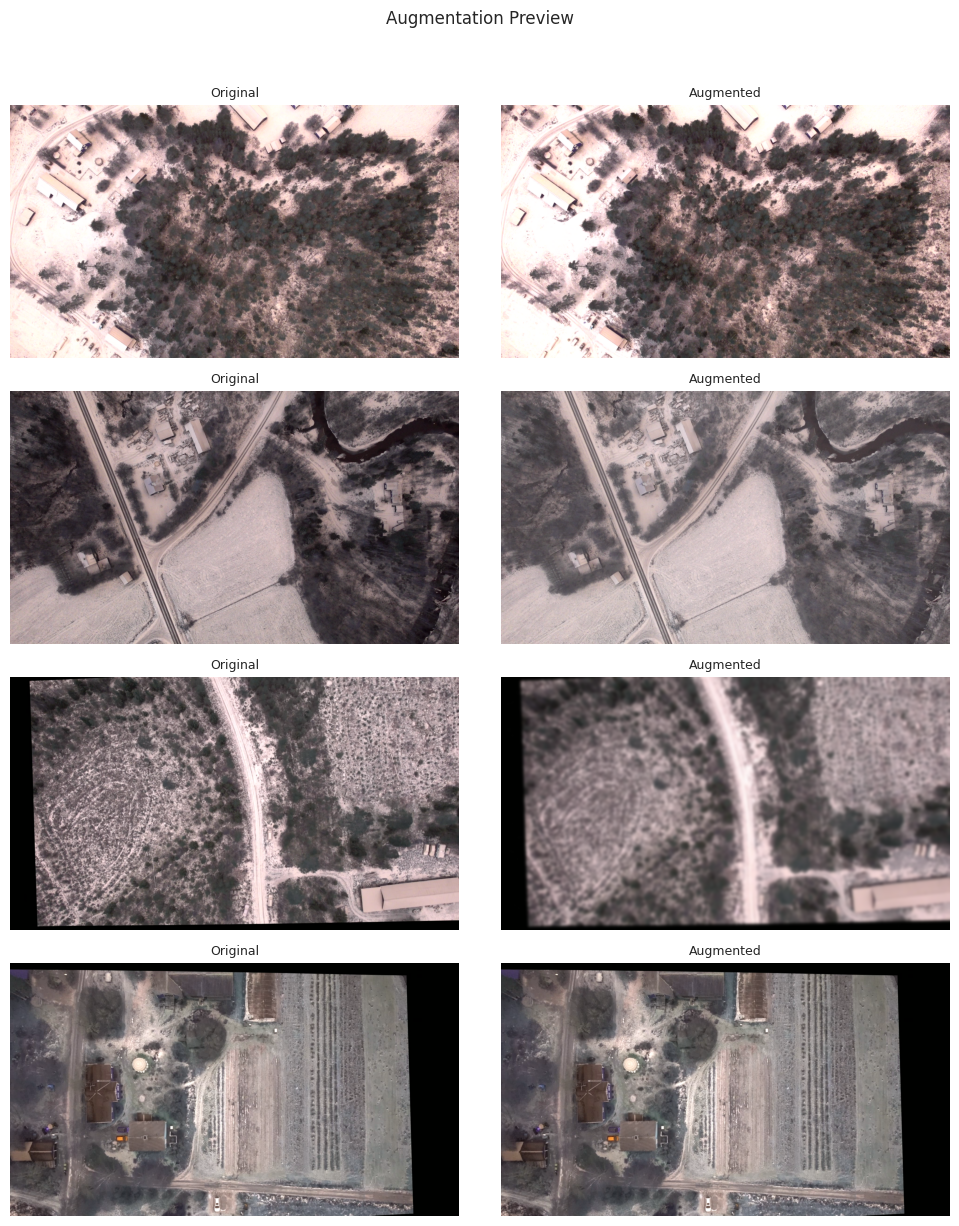

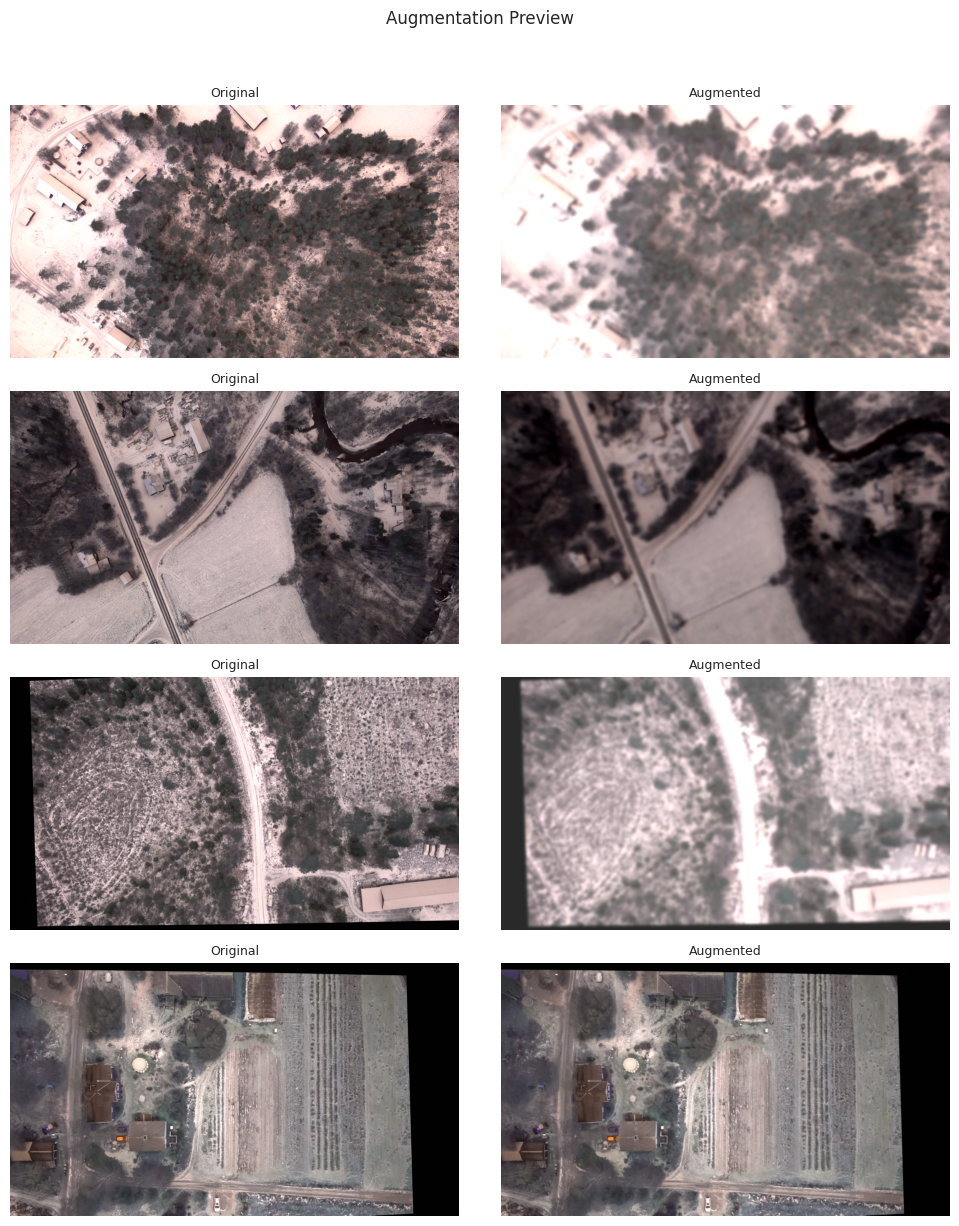

Saved previews → /Advance_deep_learning_labs/Project/results/figures


In [12]:

# ── 4.6 Augmentation preview ─────────────────────────────────────────────────
import sys
sys.path.insert(0, str(ROOT / "scripts"))
from augmentations import build_pipeline, visualize_augmentation

# Load training image paths from data.yaml
with open(DATA_YAML) as f:
    _dcfg = yaml.safe_load(f)

_root = Path(_dcfg.get("path", Path(DATA_YAML).parent))
if not _root.is_absolute():
    _root = Path(DATA_YAML).parent / _root

_train_imgs = [
    (_root / l.strip())
    for l in (_root / _dcfg["train"]).read_text().splitlines()
    if l.strip()
]

snow_pipeline = build_pipeline("snow")
full_pipeline = build_pipeline("full")

fig_snow = visualize_augmentation(_train_imgs, snow_pipeline, n=4, seed=42)
fig_snow.savefig(FIGURES / "aug_preview_snow.png", dpi=120, bbox_inches="tight")
plt.show()

fig_full = visualize_augmentation(_train_imgs, full_pipeline, n=4, seed=42)
fig_full.savefig(FIGURES / "aug_preview_full.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved previews → {FIGURES}")

### 4.9A Snow Augmentation Training (YOLOv9)

Fine-tune YOLOv9c with the **snow pipeline** injected into the training dataloader:
`RandomSnow` + `RandomFog` + `RandomBrightnessContrast`.
Same architecture, same split, same hyperparameters as section 4.2 — augmentation is the only variable.
Checkpoint saved to `models/yolov9_snow_best.pt`.


In [ ]:

# ── 4.9A YOLOv9 snow augmentation training ─────────────────────────────────────
snow_config = TrainingConfig(
    model_name="yolov9c",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=0.001,
    freeze=None,
    device=DEVICE,
    output_dir=str((MODELS_DIR / "yolov9c").resolve()),
    run_name="yolov9_snow",
    mosaic=1.0,
    close_mosaic=10,
    patience=25,
    # -- Generalization knobs (same for ALL 9 runs) --
    mixup=0.15,
    copy_paste=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.6,
)

snow_best_pt = run_yolo_fine_tuning(snow_config, aug_variant="snow")
snow_best_pt_dest = MODELS_DIR / "yolov9_snow_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(snow_best_pt, snow_best_pt_dest)
print(f"Snow-aug checkpoint → {snow_best_pt_dest}")

snow_metrics = eval_yolo_checkpoint(
    weights=snow_best_pt_dest,
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
)
append_comparison_row(snow_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {snow_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {snow_metrics.map50_95:.4f}")
print(f"Precision   : {snow_metrics.precision:.4f}")
print(f"Recall      : {snow_metrics.recall:.4f}")
print(f"FPS         : {snow_metrics.fps:.1f}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: deeplab15group (deeplab15group-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Advance_deep_learning_labs/Project/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.

wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


lr/pg0,███▇▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
lr/pg1,█████▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
lr/pg2,▃████▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▁▁▁
metrics/mAP50(B),▁▂▅▆▇███████████████████████████████████
metrics/mAP50-95(B),▁▃▃▅▅▆▅▆▆▆▇▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████
metrics/precision(B),▁▂▅▆▆▇▇▇▇▇▇▇▇█▇█████████████████████████
metrics/recall(B),▁▁▄▆▆▇▇▇▇▇▇█▇█▇▇████████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


[INFO] Best checkpoint: /Advance_deep_learning_labs/Project/models/yolov9c/yolov9_snow/weights/best.pt
Snow-aug checkpoint → /Advance_deep_learning_labs/Project/models/yolov9_snow_best.pt


Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4332.4±781.6 MB/s, size: 2729.8 KB)
val: Scanning /Advance_deep_learning_labs/Project/data/raw/labels.cache... 2904 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2904/2904 1.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 182/182 3.0it/s 1:010.3sss
                   all       2904       9175      0.988      0.991      0.994      0.879
Speed: 1.1ms preprocess, 16.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /runs/detect/val-4


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,61.2
eval/map50,0.99399
eval/map50_95,0.87871
eval/precision,0.9882
eval/recall,0.99052


[results_writer] Appended row for 'yolov9_snow_best' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9940
mAP@0.5:0.95: 0.8787
Precision   : 0.9882
Recall      : 0.9905
FPS         : 61.2


### 4.9B Full Augmentation Training (YOLOv9)

Add `GaussNoise` and `MotionBlur` on top of the snow pipeline.
Checkpoint saved to `models/yolov9_full_best.pt`.


In [ ]:

# ── 4.9B YOLOv9 full augmentation training ─────────────────────────────────────
full_config = TrainingConfig(
    model_name="yolov9c",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=0.001,
    freeze=None,
    device=DEVICE,
    output_dir=str((MODELS_DIR / "yolov9c").resolve()),
    run_name="yolov9_full",
    mosaic=1.0,
    close_mosaic=10,
    patience=25,
    # -- Generalization knobs (same for ALL 9 runs) --
    mixup=0.15,
    copy_paste=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.6,
)

full_best_pt = run_yolo_fine_tuning(full_config, aug_variant="full")
full_best_pt_dest = MODELS_DIR / "yolov9_full_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(full_best_pt, full_best_pt_dest)
print(f"Full-aug checkpoint → {full_best_pt_dest}")

full_metrics = eval_yolo_checkpoint(
    weights=full_best_pt_dest,
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
)
append_comparison_row(full_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {full_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {full_metrics.map50_95:.4f}")
print(f"Precision   : {full_metrics.precision:.4f}")
print(f"Recall      : {full_metrics.recall:.4f}")
print(f"FPS         : {full_metrics.fps:.1f}")


/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Advance_deep_learning_labs/Project/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.

lr/pg0,▃█████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▂▂▂▂▂▁▁▁
lr/pg1,███▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
lr/pg2,▃███▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁▁
metrics/mAP50(B),▁▇▇▇████████████████████████████████████
metrics/mAP50-95(B),▁▄▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
metrics/precision(B),▂▃▁▅▅▅▆▆▆▆▆▇▇▇▇█████████████████████████
metrics/recall(B),▁▅▅▇▆▇▇▇█▇▇█████████████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


[INFO] Best checkpoint: /Advance_deep_learning_labs/Project/models/yolov9c/yolov9_full/weights/best.pt
Full-aug checkpoint → /Advance_deep_learning_labs/Project/models/yolov9_full_best.pt


Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4127.3±1121.4 MB/s, size: 3383.4 KB)
val: Scanning /Advance_deep_learning_labs/Project/data/raw/labels.cache... 2904 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2904/2904 1.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 182/182 2.9it/s 1:020.3sss
                   all       2904       9175      0.989      0.989      0.994      0.879
Speed: 1.1ms preprocess, 16.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /runs/detect/val-5


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,61.2
eval/map50,0.99425
eval/map50_95,0.87874
eval/precision,0.98914
eval/recall,0.98932


[results_writer] Appended row for 'yolov9_full_best' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9942
mAP@0.5:0.95: 0.8787
Precision   : 0.9891
Recall      : 0.9893
FPS         : 61.2


### 4.10A RT-DETR Snow Augmentation Training

Fine-tune RT-DETR with the **snow pipeline**: `RandomSnow` + `RandomFog` + `RandomBrightnessContrast`.
Same architecture and hyperparameters as section 4.3 — augmentation is the only variable.
Checkpoint saved under `runs/rtdetr_snow/best_checkpoint`.


In [ ]:

# ── 4.10A RT-DETR snow augmentation training ───────────────────────────────────
rtdetr_snow_config = TrainingConfig(
    model_name="PekingU/rtdetr_r50vd",
    data_yaml="",
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=1e-5,
    freeze=None,
    device=DEVICE,
    patience=25,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_snow",
)

rtdetr_snow_dir = run_detr_fine_tuning(
    rtdetr_snow_config,
    train_json=TRAIN_COCO_JSON,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    aug_variant="snow",
)
print(f"RT-DETR snow checkpoint → {rtdetr_snow_dir}")

rtdetr_snow_metrics = eval_detr_checkpoint(
    checkpoint_dir=rtdetr_snow_dir,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    split="val",
    device_str=DEVICE,
)
append_comparison_row(rtdetr_snow_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {rtdetr_snow_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_snow_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_snow_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_snow_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_snow_metrics.fps:.1f}")


[RT-DETR] Augmentation variant: 'snow' (pre-resize to 1024px)
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([1, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([1])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([2, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([1, 256])
mod

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


...

RT-DETR snow checkpoint → /Advance_deep_learning_labs/Project/models/rtdetr/rtdetr_snow/best_checkpoint


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,7.4
eval/map50,0.97589
eval/map50_95,0.83308
eval/precision,0.9671
eval/recall,0.9805


[results_writer] Appended row for 'rtdetr-r50vd' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9759
mAP@0.5:0.95: 0.8331
Precision   : 0.9671
Recall      : 0.9805
FPS         : 7.4


### 4.10B RT-DETR Full Augmentation Training

Add `GaussNoise` and `MotionBlur` on top of the snow pipeline.
Checkpoint saved under `runs/rtdetr_full/best_checkpoint`.


In [ ]:

# ── 4.10B RT-DETR full augmentation training ───────────────────────────────────
rtdetr_full_config = TrainingConfig(
    model_name="PekingU/rtdetr_r50vd",
    data_yaml="",
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=1e-5,
    freeze=None,
    device=DEVICE,
    patience=25,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_full",
)

rtdetr_full_dir = run_detr_fine_tuning(
    rtdetr_full_config,
    train_json=TRAIN_COCO_JSON,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    aug_variant="full",
)
print(f"RT-DETR full checkpoint → {rtdetr_full_dir}")

rtdetr_full_metrics = eval_detr_checkpoint(
    checkpoint_dir=rtdetr_full_dir,
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    split="val",
    device_str=DEVICE,
)
append_comparison_row(rtdetr_full_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {rtdetr_full_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_full_metrics.map50_95:.4f}")
print(f"Precision   : {rtdetr_full_metrics.precision:.4f}")
print(f"Recall      : {rtdetr_full_metrics.recall:.4f}")
print(f"FPS         : {rtdetr_full_metrics.fps:.1f}")


[RT-DETR] Augmentation variant: 'full' (pre-resize to 1024px)
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([1, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([1])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([2, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([1, 256])
mod

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


...

RT-DETR full checkpoint → /Advance_deep_learning_labs/Project/models/rtdetr/rtdetr_full/best_checkpoint


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,7.4
eval/map50,0.98569
eval/map50_95,0.84402
eval/precision,0.9727
eval/recall,0.977


[results_writer] Appended row for 'rtdetr-r50vd' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9857
mAP@0.5:0.95: 0.8440
Precision   : 0.9727
Recall      : 0.9770
FPS         : 7.4


### 4.11A Faster R-CNN Snow Augmentation Training

Fine-tune Faster R-CNN with the **snow pipeline**: `RandomSnow` + `RandomFog` + `RandomBrightnessContrast`.
Same architecture and hyperparameters as section 4.4 — augmentation is the only variable.
Checkpoint saved to `models/frcnn_snow_best.pt`.


In [ ]:

# ── 4.11A Faster R-CNN snow augmentation training ──────────────────────────────
frcnn_snow_config = TrainingConfig(
    model_name="fasterrcnn_resnet50_fpn",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=0.005,
    freeze=None,
    device=DEVICE,
    patience=25,
    output_dir=str((MODELS_DIR / "frcnn").resolve()),
    run_name="frcnn_snow",
)

frcnn_snow_pt = run_frcnn_fine_tuning(
    frcnn_snow_config, data_yaml=DATA_YAML, aug_variant="snow"
)
frcnn_snow_dest = MODELS_DIR / "frcnn_snow_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(frcnn_snow_pt, frcnn_snow_dest)
print(f"Faster R-CNN snow checkpoint → {frcnn_snow_dest}")

frcnn_snow_metrics = eval_frcnn_checkpoint(
    weights=frcnn_snow_dest,
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
)
append_comparison_row(frcnn_snow_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {frcnn_snow_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_snow_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_snow_metrics.precision:.4f}")
print(f"Recall      : {frcnn_snow_metrics.recall:.4f}")
print(f"FPS         : {frcnn_snow_metrics.fps:.1f}")


[FRCNN] Augmentation variant: 'snow' (pre-resize to 1024px)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: deeplab15group (deeplab15group-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[FRCNN]   1/100  loss=0.2291  val_mAP@0.5=0.9537  val_mAP@0.5:0.95=0.6552
[FRCNN] ✓ best=0.9537 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_snow/best.pt
[FRCNN]   2/100  loss=0.1400  val_mAP@0.5=0.9706  val_mAP@0.5:0.95=0.7218
[FRCNN] ✓ best=0.9706 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_snow/best.pt
[FRCNN]   3/100  loss=0.1131  val_mAP@0.5=0.9730  val_mAP@0.5:0.95=0.7395
[FRCNN] ✓ best=0.9730 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_snow/best.pt
[FRCNN]   4/100  loss=0.0995  val_mAP@0.5=0.9852  val_mAP@0.5:0.95=0.7699
[FRCNN] ✓ best=0.9852 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_snow/best.pt
[FRCNN]   5/100  loss=0.0878  val_mAP@0.5=0.9786  val_mAP@0.5:0.95=0.7771
[FRCNN] No improvement (1/10)
[FRCNN]   6/100  loss=0.0807  val_mAP@0.5=0.9865  val_mAP@0.5:0.95=0.7731
[FRCNN] ✓ best=0.9865 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_snow/best.pt
[FRCNN]   7/100  loss=0.0765  val_mAP@0.5=0.9871  val_mAP@0.5:0.95

train/batch_loss,█▇▄▄█▃▃▂▁▃▂▃▁▁▂▃▃▂▁▃▂▂▁▂▂▁▂▂▂▃▁▁▂▁▂▂▂▃▂▂
train/loss,█▅▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/map50,▁▄▅▇▆████▆█▆██████▆▆▆▆▆▆▆▇▆█
val/map50_95,▁▄▅▆▆▆▇▆▇▇▇▆▇▇▇▇▇████▇█▇▇▇██
train/batch_loss,0.10023
train/loss,0.04709
val/map50,0.9882
val/map50_95,0.81786


Faster R-CNN snow checkpoint → /Advance_deep_learning_labs/Project/models/frcnn_snow_best.pt


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,6.7
eval/map50,0.98878
eval/map50_95,0.81152
eval/precision,0.9852
eval/recall,0.9826


[results_writer] Appended row for 'fasterrcnn-resnet50-fpn' → /Advance_deep_learning_labs/Project/results/model_comparison.csv

mAP@0.5     : 0.9888
mAP@0.5:0.95: 0.8115
Precision   : 0.9852
Recall      : 0.9826
FPS         : 6.7


### 4.11B Faster R-CNN Full Augmentation Training

Add `GaussNoise` and `MotionBlur` on top of the snow pipeline.
Checkpoint saved to `models/frcnn_full_best.pt`.


In [ ]:

# ── 4.11B Faster R-CNN full augmentation training ──────────────────────────────
frcnn_full_config = TrainingConfig(
    model_name="fasterrcnn_resnet50_fpn",
    data_yaml=DATA_YAML,
    epochs=200,
    batch=4,
    imgsz=1024,
    lr0=0.005,
    freeze=None,
    device=DEVICE,
    patience=25,
    output_dir=str((MODELS_DIR / "frcnn").resolve()),
    run_name="frcnn_full",
)

frcnn_full_pt = run_frcnn_fine_tuning(
    frcnn_full_config, data_yaml=DATA_YAML, aug_variant="full"
)
frcnn_full_dest = MODELS_DIR / "frcnn_full_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(frcnn_full_pt, frcnn_full_dest)
print(f"Faster R-CNN full checkpoint → {frcnn_full_dest}")

frcnn_full_metrics = eval_frcnn_checkpoint(
    weights=frcnn_full_dest,
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
)
append_comparison_row(frcnn_full_metrics, COMPARISON_CSV)

print(f"\nmAP@0.5     : {frcnn_full_metrics.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_full_metrics.map50_95:.4f}")
print(f"Precision   : {frcnn_full_metrics.precision:.4f}")
print(f"Recall      : {frcnn_full_metrics.recall:.4f}")
print(f"FPS         : {frcnn_full_metrics.fps:.1f}")


[FRCNN] Augmentation variant: 'full' (pre-resize to 1024px)


/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


[FRCNN]   1/100  loss=0.2236  val_mAP@0.5=0.9552  val_mAP@0.5:0.95=0.6516
[FRCNN] ✓ best=0.9552 → /Advance_deep_learning_labs/Project/models/frcnn/frcnn_full/best.pt


### 4.12 Augmentation Ablation Results

Compare val-set mAP across **all 9 combinations** (3 models × 3 aug variants) and produce
a grouped bar chart.  Saves `results/figures/aug_ablation_bar.png` for the presentation slides.


In [ ]:

# ── 4.12 Augmentation ablation results — read from CSV (no model loading) ──────
# Each training cell (4.2–4.11B) already appends its val metrics to the CSV.
# This cell simply reads the accumulated results and visualises them.

df_comp = pd.read_csv(COMPARISON_CSV)

# Keep only fine-tuned val-set rows (exclude zero-shot baselines)
df_aug = df_comp[(df_comp["Fine-tuned"] == "True") & (df_comp["Split"] == "val")].copy()

# Parse numeric columns (they may be stored as strings)
for col in ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "FPS"]:
    df_aug[col] = pd.to_numeric(df_aug[col], errors="coerce")

# Drop duplicates (keep last run if a model was retrained)
df_aug = df_aug.drop_duplicates(subset=["Model"], keep="last").reset_index(drop=True)

print(f"Loaded {len(df_aug)} ablation rows from {COMPARISON_CSV}\n")

numeric = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "FPS"]

display(
    df_aug[["Model"] + numeric].style
      .highlight_max(subset=numeric, color="lightgreen")
      .format({c: "{:.4f}" for c in numeric if c != "FPS"})
      .format({"FPS": "{:.1f}"})
      .set_caption("4.12 — Augmentation Ablation (val set, all models)")
)

# ── Grouped bar chart ─────────────────────────────────────────────────────────
_model_prefixes = ["YOLOv9c", "RT-DETR", "Faster R-CNN"]
_variants       = ["no aug", "snow", "full"]
_variant_labels = ["no aug", "snow aug", "full aug"]
_colors         = ["steelblue", "orange", "green"]
x = np.arange(len(_model_prefixes))
bar_w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (variant, vlabel, color) in enumerate(zip(_variants, _variant_labels, _colors)):
    vals = []
    for mp in _model_prefixes:
        row = df_aug[df_aug["Model"].str.contains(mp) & df_aug["Model"].str.contains(variant)]
        vals.append(row["mAP@0.5"].values[0] if len(row) > 0 else 0.0)
    bars = ax.bar(x + (i - 1) * bar_w, vals, bar_w,
                  label=vlabel, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f"{v:.3f}", ha="center", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(_model_prefixes)
ax.set_ylabel("mAP@0.5")
ax.set_ylim(0, 1)
ax.set_title("Augmentation Ablation — All Models (val set)")
ax.legend(title="Augmentation")
plt.tight_layout()
fig.savefig(FIGURES / "aug_ablation_bar.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES / 'aug_ablation_bar.png'}")


### 4.13 Select the Model

Pick the single best checkpoint across all 3 architectures × 3 augmentation variants
based on **val mAP@0.5** (the primary metric throughout training).
This checkpoint is highlighted in the final test-set evaluation in section 4.14.


In [ ]:

# ── 4.13 Build checkpoint map & identify best val model ────────────────────────
# Reads comparison CSV, picks best val mAP@0.5, and builds the checkpoint map
# used by both 4.14 (test metrics) and Section 6 (error analysis).

df_comp = pd.read_csv(COMPARISON_CSV)
df_val = df_comp[(df_comp["Fine-tuned"] == "True") & (df_comp["Split"] == "val")].copy()
df_val["mAP@0.5"] = pd.to_numeric(df_val["mAP@0.5"], errors="coerce")
df_val = df_val.drop_duplicates(subset=["Model"], keep="last").reset_index(drop=True)

best_idx = df_val["mAP@0.5"].idxmax()
BEST_MODEL = df_val.loc[best_idx, "Model"]
BEST_MAP50 = df_val.loc[best_idx, "mAP@0.5"]

# Checkpoint map — used by infer_all_models() in 4.14 and Section 6
_CHECKPOINT_MAP = {
    "YOLOv9c · no aug":         {"type": "yolo",  "imgsz": 1024, "path": MODELS_DIR / "yolov9_nvd_best.pt"},
    "YOLOv9c · snow aug":       {"type": "yolo",  "imgsz": 1024, "path": MODELS_DIR / "yolov9_snow_best.pt"},
    "YOLOv9c · full aug":       {"type": "yolo",  "imgsz": 1024, "path": MODELS_DIR / "yolov9_full_best.pt"},
    "RT-DETR · no aug":         {"type": "detr",  "imgsz": 1024, "path": (MODELS_DIR / "rtdetr" / "rtdetr_nvd"  / "best_checkpoint").resolve()},
    "RT-DETR · snow aug":       {"type": "detr",  "imgsz": 1024, "path": (MODELS_DIR / "rtdetr" / "rtdetr_snow" / "best_checkpoint").resolve()},
    "RT-DETR · full aug":       {"type": "detr",  "imgsz": 1024, "path": (MODELS_DIR / "rtdetr" / "rtdetr_full" / "best_checkpoint").resolve()},
    "Faster R-CNN · no aug":    {"type": "frcnn", "imgsz": 1024, "path": MODELS_DIR / "frcnn_nvd_best.pt"},
    "Faster R-CNN · snow aug":  {"type": "frcnn", "imgsz": 1024, "path": MODELS_DIR / "frcnn_snow_best.pt"},
    "Faster R-CNN · full aug":  {"type": "frcnn", "imgsz": 1024, "path": MODELS_DIR / "frcnn_full_best.pt"},
}

print(f"Best model (val): {BEST_MODEL}  (mAP@0.5 = {BEST_MAP50:.4f})")
print(f"\nCheckpoint map ({len(_CHECKPOINT_MAP)} models):")
for name, info in _CHECKPOINT_MAP.items():
    status = "✓" if info["path"].exists() else "✗ MISSING"
    print(f"  {status}  {name}")


### 4.14 Test-Set Evaluation (All 9 Models)

Single inference pass over the held-out test split (`Bjenberg 02_stabilized`).
Produces:
1. **Metrics table** — mAP, Precision, Recall for all 9 checkpoints → `test_results.csv`
2. **Raw predictions** — `_all_inferences` dict reused by Section 6 (error analysis)

> The test set is touched **only once** — all model selection was done on val.

In [ ]:

# ── 4.14 Test-set evaluation — single inference pass for all 9 models ─────────
# Runs inference ONCE per model. Produces:
#   1. test_rows / df_test  → metrics table + test_results.csv
#   2. _all_inferences      → raw per-image predictions (reused by Section 6)
#
# Prerequisites:
#   - _CHECKPOINT_MAP defined in 4.13
#   - test_split loaded in EDA (Section 2)

from analysis import collect_test_items, infer_all_models
from training.evaluator import best_precision_recall

# Collect GT items from test split
_test_items = collect_test_items(test_split)
print(f"Test set: {len(_test_items)} images\n")

# Run inference on all 9 models (loads each model once, then frees GPU memory)
_all_inferences = infer_all_models(_CHECKPOINT_MAP, _test_items, device_str=DEVICE)

# Compute metrics from raw predictions (no model re-loading needed)
test_rows = []
for model_name, preds in _all_inferences.items():
    if preds is None:
        continue

    # Compute mAP using torchmetrics
    from torchmetrics.detection import MeanAveragePrecision
    import torch

    metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=False)
    metric_full = MeanAveragePrecision(class_metrics=False)

    for p in preds:
        pred_dict = {
            "boxes":  torch.tensor(p["pred_boxes"], dtype=torch.float32),
            "scores": torch.tensor(p["pred_scores"], dtype=torch.float32),
            "labels": torch.zeros(len(p["pred_boxes"]), dtype=torch.int64),
        }
        gt_dict = {
            "boxes":  torch.tensor(p["gt"], dtype=torch.float32) if p["gt"] else torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros(len(p["gt"]), dtype=torch.int64),
        }
        metric.update([pred_dict], [gt_dict])
        metric_full.update([pred_dict], [gt_dict])

    map50_result = metric.compute()
    map_full_result = metric_full.compute()
    map50 = float(map50_result["map"].item())
    map50_95 = float(map_full_result["map"].item())

    # Precision/Recall at best F1 threshold
    prec, rec = best_precision_recall(preds, iou_thresh=0.5)

    test_rows.append({
        "Model": model_name,
        "mAP@0.5": map50,
        "mAP@0.5:0.95": map50_95,
        "Precision": prec,
        "Recall": rec,
    })

# ── Results table ─────────────────────────────────────────────────────────────
if test_rows:
    df_test = pd.DataFrame(test_rows)
    numeric = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]

    best_test_row = df_test.loc[df_test["mAP@0.5"].idxmax()]
    BEST_TEST_MODEL = best_test_row["Model"]
    print(f"\n>>> Best model on test set: {BEST_TEST_MODEL}  "
          f"(mAP@0.5 = {best_test_row['mAP@0.5']:.4f})\n")

    display(
        df_test.style
          .highlight_max(subset=numeric, color="lightgreen")
          .apply(lambda row: ["font-weight: bold" if row["Model"] == BEST_TEST_MODEL
                              else "" for _ in row], axis=1)
          .format({c: "{:.4f}" for c in numeric})
          .set_caption("4.14 — Test-Set Results (held-out location, all 9 models)")
    )

    df_test.to_csv(str(RESULTS / "test_results.csv"), index=False)
    print(f"Saved → {RESULTS / 'test_results.csv'}")
else:
    print("No models found — train models first (sections 4.2–4.11B).")


## 5. Evaluation

In [ ]:

# ── Section 5 — Test results loaded from CSV (for re-viewing without re-running) 
# If you've already run 4.14 in this session, df_test is already in memory.
# This cell lets you reload results in a fresh kernel without re-running inference.

_test_csv = RESULTS / "test_results.csv"

if _test_csv.exists():
    df_test = pd.read_csv(_test_csv)
    numeric = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]
    BEST_TEST_MODEL = df_test.loc[df_test["mAP@0.5"].idxmax(), "Model"]

    print(f"Best model on test set: {BEST_TEST_MODEL}\n")
    display(
        df_test.style
          .highlight_max(subset=numeric, color="lightgreen")
          .format({c: "{:.4f}" for c in numeric})
          .set_caption("Final Results — Held-out Test Set (from CSV)")
    )
else:
    print("test_results.csv not found — run section 4.14 first.")


## 6. Error Analysis

Qualitative failure analysis on the **held-out test set** for **all 9 trained models**
(YOLOv9c · RT-DETR · Faster R-CNN × none / snow / full augmentation).

Three failure categories are examined per model:

| Category | Definition |
|---|---|
| **False Negatives** | Cars present in the image that were not detected (IoU < 0.5 with every prediction) |
| **False Positives** | Predictions with no matching ground-truth car (IoU < 0.5 with every GT box) |
| **Poor Localisation** | Car detected but IoU with the ground truth falls in [0.3, 0.5) |

Confidence threshold applied before matching: **conf ≥ 0.3**.

> **Note:** Raw per-image predictions (`_all_inferences`) are produced by section 4.14.
> No model re-loading happens here — this section only categorises and visualises.

- **6.1** — Verify inference results are in memory
- **6.2** — `categoriser.py` · IoU-matches predictions vs GT; `reporter.py` · summary table
- **6.3** — `reporter.py` · grouped bar chart; `visualiser.py` · failure grids

In [ ]:

# ── 6.1  Verify inference results are available ───────────────────────────────
# _all_inferences was produced by section 4.14 (single inference pass).
# If running from a fresh kernel without 4.14, re-run 4.14 first.

if "_all_inferences" not in dir() or not _all_inferences:
    raise RuntimeError(
        "_all_inferences not found — run section 4.14 first.\n"
        "Section 4.14 runs inference once and produces both metrics and raw predictions."
    )

present = sum(1 for v in _all_inferences.values() if v is not None)
print(f"Inference results available: {present}/{len(_CHECKPOINT_MAP)} models.")
print("Proceeding to error categorisation...")


In [ ]:

# ── 6.2  Categorise errors for every model ────────────────────────────────────
# Uses scripts/analysis/categoriser.py (SRP: IoU-matching & classification).
# Uses scripts/analysis/reporter.py    (SRP: summary table & CSV).

from analysis import categorise_all_models
from analysis.reporter import build_summary_df, save_summary_csv

_all_errors = categorise_all_models(_all_inferences)

df_errors = build_summary_df(_all_errors)
save_summary_csv(df_errors, RESULTS / "error_analysis_summary.csv")

# Style: green = fewest errors (best), red = most errors (worst)
_numeric_cols = ["False Negatives", "False Positives", "Poor Localisation"]
display(
    df_errors.style
    .highlight_min(subset=_numeric_cols, color="lightgreen")
    .highlight_max(subset=_numeric_cols, color="#ffcccc")
    .set_caption("Error Analysis — all 9 models  (test set · conf ≥ 0.3)")
)


In [ ]:

# ── 6.3  Visualise failure grids for all models ───────────────────────────────
# Uses scripts/analysis/reporter.py    (SRP: bar chart).
# Uses scripts/analysis/visualiser.py  (SRP: image rendering & grid export).

from analysis.reporter   import plot_error_bar_chart
from analysis.visualiser import save_all_grids

# Grouped bar chart — FN / FP / Poor per model
fig = plot_error_bar_chart(_all_errors, save_path=FIGURES / "error_analysis_summary.png")
plt.show()

# Failure grids — 9-panel crops for every error type, every model.
# Grids for BEST_MODEL are shown inline; all others are saved only.
print("\nSaving failure grids …")
save_all_grids(_all_errors, figures_dir=FIGURES, best_model=BEST_MODEL)
